In [75]:
import cme.decision_models.confidence_accumulation as ca
import cme.decision_models.quantum_discrete as qd
import cme.decision_models.diffusion_discrete as dd

import jax.numpy as npx
import jax.scipy as scx
import pandas as pd
import seaborn as sns
import numpy as np
import seaborn.objects as so
import matplotlib.pyplot as plt
sns.set_context("paper", font_scale=3.5)

No GPU/TPU found, falling back to CPU. (Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)


In [76]:
n_states, start_width, delta, measurement_prob,  I, J, steps = 7, 1, 1, 0.8, 1, 1, 0.1
m_Mc, m_Mw, m_Mn = ca._get_measurement_matrix(n_states, 1, prob=measurement_prob, model_type = "Markov")
q_Mc, q_Mw, q_Mn = ca._get_measurement_matrix(n_states, 1, prob=measurement_prob, model_type = "Quantum")


In [77]:
m_mu, m_sigma, T = npx.asarray([[1]]), npx.asarray([[2]]), 100
q_mu, q_sigma, T = npx.asarray([[1]]), npx.asarray([[1]]), 100

intensity_matrix_markov = dd._buildK(n_states, m_mu, m_sigma)
intensity_matrix_quantum = qd._buildH(n_states, q_mu, q_sigma)


In [78]:
phi_0_markov = ca._get_initial_state(n_states, start_width,model_type="Markov", prior_type="Upper")
phi_0_quantum = ca._get_initial_state(n_states, start_width,model_type="Quantum" , prior_type="Upper")
phi_0_markov, phi_0_quantum

(Array([[[[0.],
          [0.],
          [0.],
          [0.],
          [0.],
          [0.],
          [1.]]]], dtype=float64),
 Array([[[[0.],
          [0.],
          [0.],
          [0.],
          [0.],
          [0.],
          [1.]]]], dtype=float64))

In [79]:
df_markov = pd.DataFrame()
df_quantum = pd.DataFrame()
for prior_type in ["Upper", "Uniform", "Lower"]:
    phi_0_markov = ca._get_initial_state(n_states, start_width,model_type="Markov", prior_type=prior_type)
    phi_0_quantum = ca._get_initial_state(n_states, start_width,model_type="Quantum" , prior_type=prior_type)

    phi_markov_arr = []
    phi_quantum_arr = []
    for t in np.arange(1,20,0.1):
        phi_markov = ca.perform_state_transition(intensity_matrix_markov, npx.asarray([[t]]), npx.asarray([[1]]), 
                                                m_Mc, m_Mw, m_Mn, phi_0_markov, delta, 
                                                transition_type="RT", likelihood_type="SINGLE")
        phi_markov_arr.append(np.asarray(phi_markov.squeeze()))
    for t in np.arange(1,20,0.1):
        phi_quantum = ca.perform_state_transition(intensity_matrix_quantum, npx.asarray([[t]]), npx.asarray([[1]]), 
                                                q_Mc, q_Mw, q_Mn, phi_0_quantum, delta, 
                                                transition_type="RT", likelihood_type="SINGLE")
        phi_quantum_arr.append(np.abs(phi_quantum.squeeze())**2)
    
    df_markov = pd.concat([df_markov, pd.DataFrame(phi_markov_arr).T.assign(prior=prior_type)])
    df_quantum = pd.concat([df_quantum, pd.DataFrame(phi_quantum_arr).T.assign(prior=prior_type)])
        

In [80]:
intensity_matrix_markov

Array([[[[-2. ,  0.5,  0. ,  0. ,  0. ,  0. ,  0. ],
         [ 2. , -2. ,  0.5,  0. ,  0. ,  0. ,  0. ],
         [ 0. ,  1.5, -2. ,  0.5,  0. ,  0. ,  0. ],
         [ 0. ,  0. ,  1.5, -2. ,  0.5,  0. ,  0. ],
         [ 0. ,  0. ,  0. ,  1.5, -2. ,  0.5,  0. ],
         [ 0. ,  0. ,  0. ,  0. ,  1.5, -2. ,  2. ],
         [ 0.5,  0. ,  0. ,  0. ,  0. ,  1.5, -2. ]]]], dtype=float64)

In [81]:
pd.DataFrame(scx.linalg.expm(intensity_matrix_markov*20).squeeze())

,0,1,2,3,4,5,6
0,0.001904,0.001557,0.001440,0.001401,0.001388,0.001385,0.001384
1,0.007611,0.006224,0.005760,0.005605,0.005555,0.005541,0.005539
2,0.022821,0.018665,0.017280,0.016822,0.016675,0.016634,0.016628
3,0.068453,0.055988,0.051850,0.050489,0.050056,0.049935,0.049917
4,0.205407,0.168009,0.155616,0.151553,0.150267,0.149907,0.149856
5,0.616533,0.504289,0.467119,0.454951,0.451106,0.450031,0.449877
6,0.462703,0.378466,0.350574,0.341444,0.338560,0.337754,0.337639


In [82]:
df_markov_plot = df_markov.melt(id_vars = "prior", ignore_index=False, var_name="time").assign(time = lambda df:df.time*0.1).reset_index(names="states").assign(states = lambda df: df.states - n_states//2 )
df_quantum_plot = df_quantum.melt(id_vars = "prior", ignore_index=False, var_name="time").assign(time = lambda df:df.time*0.1).reset_index(names="states").assign(states = lambda df: df.states - n_states//2)
df_markov_plot

,states,prior,time,value
0,-3,Upper,0.0,0.000013
1,-2,Upper,0.0,0.000166
2,-1,Upper,0.0,0.001717
3,0,Upper,0.0,0.014567
4,1,Upper,0.0,0.096796
11,1,Uniform,0.0,0.142857
3985,-1,Lower,18.9,0.022821
3986,0,Lower,18.9,0.068451
3987,1,Lower,18.9,0.205394
3988,2,Lower,18.9,0.616488


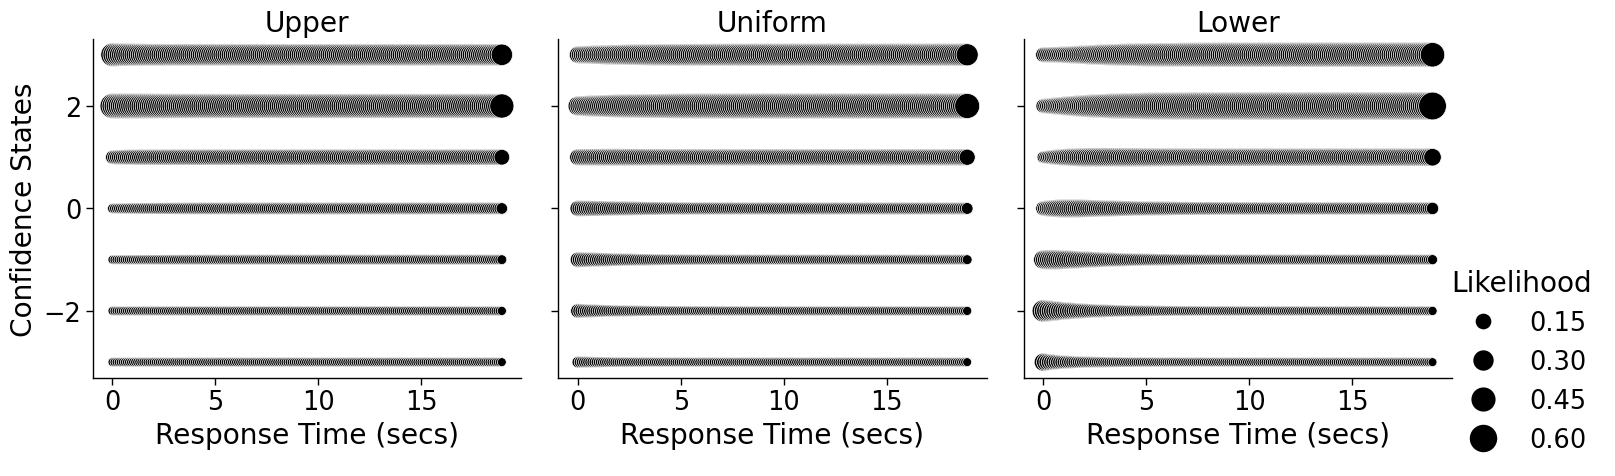

In [83]:
f = sns.relplot(df_markov_plot,
x="time", y="states",size="value", col="prior", sizes=(40,400), color="Black", aspect=1)
f.set_titles("{col_name}")
f.legend.set_title("Likelihood")
f.set_xlabels("Response Time (secs)")
f.set_ylabels("Confidence States")
#f.legend.set_bbox_to_anchor((0.9,0.5))
f.legend.set_loc("lower right")

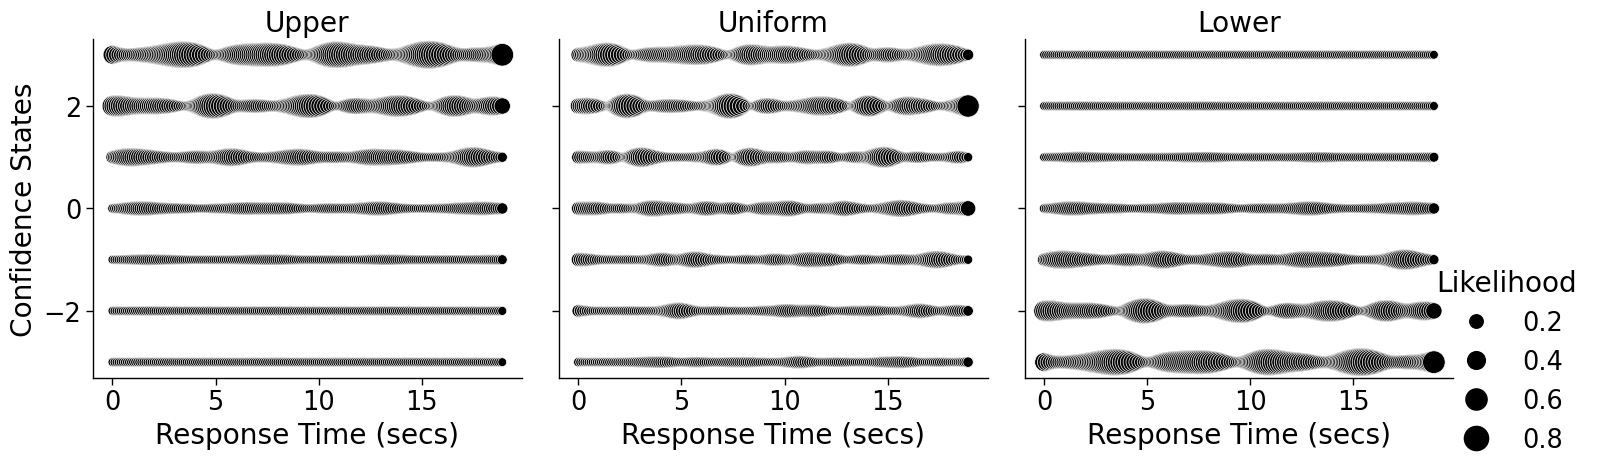

In [74]:
f = sns.relplot(df_quantum_plot,
x="time", y="states",size="value", col="prior", sizes=(40,400), color="Black")
f.set_titles("{col_name}")
f.legend.set_title("Likelihood")
f.set_xlabels("Response Time (secs)")
f.set_ylabels("Confidence States")
f.legend.set_loc("lower right")

In [11]:
mv = np.arange(-(n_states//2), (n_states//2)+1)
mv

array([-3, -2, -1,  0,  1,  2,  3])

In [38]:
df_markov1 = pd.DataFrame()
df_quantum1 = pd.DataFrame()

for mu in [npx.asarray([[0.01]]), npx.asarray([[0.1]]), npx.asarray([[0.5]]), npx.asarray([[1]])]:
    intensity_matrix_markov = dd._buildK(n_states, mu, m_sigma)
    intensity_matrix_quantum = qd._buildH(n_states, mu, q_sigma)
    print(intensity_matrix_markov)
    for prior_type in ["Upper", "Uniform", "Lower"]:
        phi_0_markov = ca._get_initial_state(n_states, start_width,model_type="Markov", prior_type=prior_type)
        phi_0_quantum = ca._get_initial_state(n_states, start_width,model_type="Quantum" , prior_type=prior_type)
        
        phi_markov_arr = []
        phi_quantum_arr = []
        for t in np.arange(1,20,0.1):
            phi_markov = ca.perform_state_transition(intensity_matrix_markov, npx.asarray([[t]]), npx.asarray([[1]]), 
                                                    m_Mc, m_Mw, m_Mn, phi_0_markov, delta, 
                                                    transition_type="RT", likelihood_type="SINGLE")
            phi_markov_arr.append(np.asarray(phi_markov.squeeze() @ mv))
        for t in np.arange(1,20,0.1):
            phi_quantum = ca.perform_state_transition(intensity_matrix_quantum, npx.asarray([[t]]), npx.asarray([[1]]), 
                                                    q_Mc, q_Mw, q_Mn, phi_0_quantum, delta, 
                                                    transition_type="RT", likelihood_type="SINGLE")
            phi_quantum_arr.append((np.abs(phi_quantum.squeeze())**2) @ mv)
        
        df_markov1 = pd.concat([df_markov1, pd.DataFrame(phi_markov_arr).T.assign(prior=prior_type, mu=f"({np.asarray(mu[0,0])}, {np.asarray(sigma_m[0,0])})")])
        df_quantum1 = pd.concat([df_quantum1, pd.DataFrame(phi_quantum_arr).T.assign(prior=prior_type, mu=f"({np.asarray(mu[0,0])}, {np.asarray(sigma_m[0,0])})")])
        

[[[[-2.     0.995  0.     0.     0.     0.     0.   ]
   [ 2.    -2.     0.995  0.     0.     0.     0.   ]
   [ 0.     1.005 -2.     0.995  0.     0.     0.   ]
   [ 0.     0.     1.005 -2.     0.995  0.     0.   ]
   [ 0.     0.     0.     1.005 -2.     0.995  0.   ]
   [ 0.     0.     0.     0.     1.005 -2.     2.   ]
   [ 0.995  0.     0.     0.     0.     1.005 -2.   ]]]]
[[[[-2.    0.95  0.    0.    0.    0.    0.  ]
   [ 2.   -2.    0.95  0.    0.    0.    0.  ]
   [ 0.    1.05 -2.    0.95  0.    0.    0.  ]
   [ 0.    0.    1.05 -2.    0.95  0.    0.  ]
   [ 0.    0.    0.    1.05 -2.    0.95  0.  ]
   [ 0.    0.    0.    0.    1.05 -2.    2.  ]
   [ 0.95  0.    0.    0.    0.    1.05 -2.  ]]]]
[[[[-2.    0.75  0.    0.    0.    0.    0.  ]
   [ 2.   -2.    0.75  0.    0.    0.    0.  ]
   [ 0.    1.25 -2.    0.75  0.    0.    0.  ]
   [ 0.    0.    1.25 -2.    0.75  0.    0.  ]
   [ 0.    0.    0.    1.25 -2.    0.75  0.  ]
   [ 0.    0.    0.    0.    1.25 -2.    2.  ]
   [ 

In [39]:
df_markov1_plot = df_markov1.melt(id_vars=["prior", "mu"], var_name="time").assign(time=lambda df: df.time*0.1)
df_quantum1_plot = df_quantum1.melt(id_vars=["prior", "mu"], var_name="time").assign(time=lambda df: df.time*0.1)
df_markov1_plot.query("value > 3")

,prior,mu,time,value


In [40]:
df_markov1_plot

,prior,mu,time,value
0,Upper,0.01,0.0,1.956576
1,Uniform,0.01,0.0,0.259535
2,Lower,0.01,0.0,-0.760949
3,Upper,0.10,0.0,1.989935
4,Uniform,0.10,0.0,0.302106
...,...,...,...,...
2275,Uniform,0.50,18.9,1.916500
2276,Lower,0.50,18.9,2.792542
2277,Upper,1.00,18.9,2.030529
2278,Uniform,1.00,18.9,2.188311


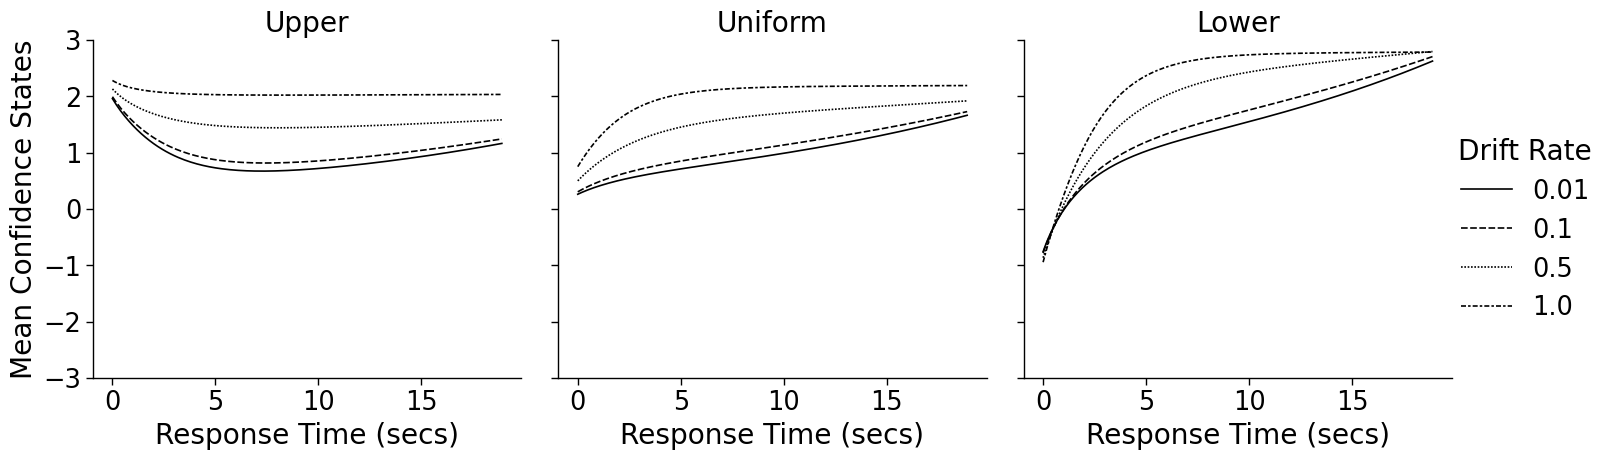

In [41]:
P_markov_t1.shape

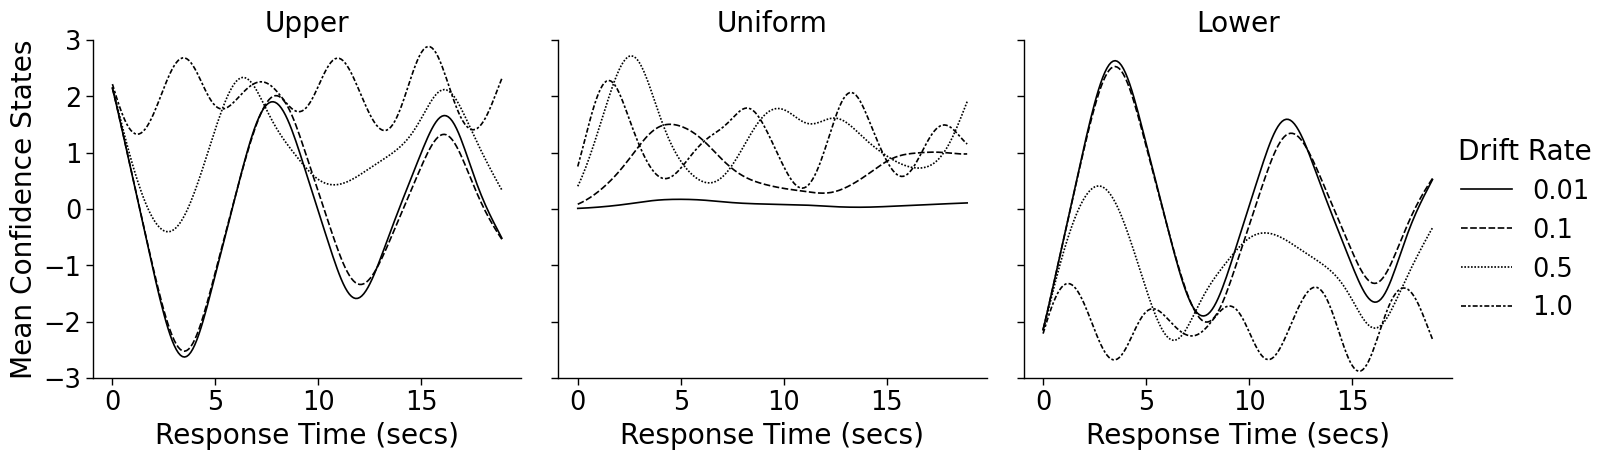

In [42]:
(m_Mn_i @ P_markov_t1).reshape(7,-1).shape

In [25]:
P_markov_t.sum(), (m_Mn_i @ P_markov_t1).reshape(-1,7) @ np.eye(n_states) @ (m_Mc @ P_markov_t2).reshape(7,-1)

(Array(0.79171667, dtype=float64), Array([[0.01236979]], dtype=float64))

In [26]:
(m_Mc @ P_markov_t2).sum()

Array(0.33155349, dtype=float64)

In [27]:
(m_Mn_i @ P_markov_t1).sum()

Array(0.64236168, dtype=float64)

In [28]:
P_markov_t.sum(), (m_Mc @ P_markov_t2).sum()  + (m_Mn_i @ P_markov_t1).sum()

(Array(0.79171667, dtype=float64), Array(0.97391516, dtype=float64))

In [29]:
n=2
m_Mn_i = (npx.eye(n_states) - m_Mc)/n


In [30]:
m_Mn_i

Array([[0.5, 0. , 0. , 0. , 0. , 0. , 0. ],
       [0. , 0.5, 0. , 0. , 0. , 0. , 0. ],
       [0. , 0. , 0.5, 0. , 0. , 0. , 0. ],
       [0. , 0. , 0. , 0.5, 0. , 0. , 0. ],
       [0. , 0. , 0. , 0. , 0.5, 0. , 0. ],
       [0. , 0. , 0. , 0. , 0. , 0.5, 0. ],
       [0. , 0. , 0. , 0. , 0. , 0. , 0.1]], dtype=float64)

In [31]:
t = 7
t1 = 2
t2 = 1
t3 = t - (t1+t2)

P_markov_t = ca.perform_state_transition(intensity_matrix_markov, npx.asarray([[t]]), npx.asarray([[1]]), 
                                                m_Mc, m_Mw, m_Mn, phi_0_markov, delta, 
                                                transition_type="RT", likelihood_type="SINGLE")

P_markov_t1 = ca.perform_state_transition(intensity_matrix_markov, npx.asarray([[t1]]), npx.asarray([[1]]), 
                                                m_Mc, m_Mw, m_Mn, phi_0_markov, delta, 
                                                transition_type="RT", likelihood_type="SINGLE")

P_markov_t2 = ca.perform_state_transition(intensity_matrix_markov, npx.asarray([[t2]]), npx.asarray([[1]]), 
                                                m_Mc, m_Mw, m_Mn, phi_0_markov, delta, 
                                                transition_type="RT", likelihood_type="SINGLE")

P_markov_t3 = ca.perform_state_transition(intensity_matrix_markov, npx.asarray([[t3]]), npx.asarray([[1]]), 
                                                m_Mc, m_Mw, m_Mn, phi_0_markov, delta, 
                                                transition_type="RT", likelihood_type="SINGLE")

P_markov_t.sum(), (m_Mc @ P_markov_t3).sum()  + (m_Mn_i @ P_markov_t2).sum() + (m_Mn_i @ P_markov_t1).sum()

(Array(0.79185982, dtype=float64), Array(1.13334476, dtype=float64))